# Cingulate cortex (CC) snATAC processing

In [2]:
import warnings
warnings.simplefilter(action='ignore')
import pandas as pd
import pycisTopic
pycisTopic.__version__
import polars as pl
import glob
import os
import pickle
from pycisTopic.qc import *
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import importlib
import pprint as pp
from IPython.display import Image, display
%matplotlib inline

In [11]:
#set up
proj_dir = 'snATAC_analysis/'
proj_subdir = proj_dir + '/CC/'
out = proj_subdir + 'out/'
tmp = '/scratch/'
data_dir = 'data/'

## 0. Loading data

In [ ]:
# load metadata
metadata_path = data_dir + 'atac_samples_metadata_with_donor_region_info.csv"
metadata = pl.read_csv(metadata_path)
# select CC samples
metadata = (metadata.filter((pl.col("brain_region") == "cyngulate_cortex")).sort(pl.col("short_bc_id")))
metadata

In [ ]:
#fragments files
fragments_dict = {
    os.path.basename(x).split(".")[0]: x
    for x in sorted(
        sorted(
            glob.glob(
                data_dir+"fragments/*.fragments.raw.tsv.gz"
            )
        )
    )
}
fragments_dict = dict((k, fragments_dict[k]) for k in metadata['short_bc_id'])

## 1. QC

### 1.1 QC for samples with CC donors only

In [ ]:
cistopic_qc_out = out+'QC/'
if not os.path.exists(cistopic_qc_out):
    os.makedirs(cistopic_qc_out)

In [ ]:
fragments_sub_dict = {}
for sample in fragments_dict.keys():
    metadata_file = os.path.join(cistopic_qc_out, sample + ".fragments_stats_per_cb.parquet")
    print(f"Checking if {metadata_file} exist...")
    if os.path.exists(metadata_file):
        print("\tQC file exists! Skipping...")
    else:
        fragments_sub_dict[sample] = fragments_dict[sample]
        print("\tQC file does not exist, adding to subdict to generate")

In [30]:
## create file with QC commands
regions_bed_filename = data_dir + 'CC_CT1_final_consensus_regions.bed'
tss_bed_filename = data_dir + "T2T_TSS_full.bed"
pycistopic_qc_commands_filename = out + "/QC/QC_commands.txt"

with open(pycistopic_qc_commands_filename, "w") as fh:
    for sample, fragment_filename in fragments_sub_dict.items():
        print(
            "singularity exec -B pycistopic_2.0a.sif pycistopic qc",
            f"--fragments {fragment_filename}",
            f"--regions {regions_bed_filename}",
            f"--tss {tss_bed_filename}",
            f"--output {os.path.join(out, 'QC/')}/{sample}",
            sep=" ",
            file=fh,
        )

In [ ]:
! cat out/QC/QC_commands.txt | parallel -j 4 {}

In [8]:
from pycisTopic.plotting.qc_plot import plot_sample_stats, plot_barcode_stats
import matplotlib.pyplot as plt

In [9]:
fragments_sub_dict = {}
fragments_sub_dict_avail = {}
for sample in fragments_dict.keys():
    metadata_file = os.path.join(cistopic_qc_out, sample + ".fragments_stats_per_cb.parquet")
    if os.path.exists(metadata_file):
        fragments_sub_dict_avail[sample] = fragments_dict[sample]
    else:
        fragments_sub_dict[sample] = fragments_dict[sample]

In [ ]:
## create sample QC plots
for sample_id in fragments_sub_dict_avail:
    fig = plot_sample_stats(
        sample_id = sample_id,
        pycistopic_qc_output_dir = out+'/QC/',save=out+f'/QC/plots/{sample_id}_sample_stats.png'

    )

In [ ]:
## Select barcodes with TSS > 5 and nr unique fragments in peaks > 1000
from pycisTopic.qc import get_barcodes_passing_qc_for_sample
sample_id_to_barcodes_passing_filters = {}
sample_id_to_thresholds = {}
for sample_id in fragments_sub_dict_avail:
    (
        sample_id_to_barcodes_passing_filters[sample_id],
        sample_id_to_thresholds[sample_id]
    ) = get_barcodes_passing_qc_for_sample(
            sample_id = sample_id,
            pycistopic_qc_output_dir =  out+'/QC/',
            unique_fragments_threshold = 1000,
            tss_enrichment_threshold = 5,
            frip_threshold = 0,
            use_automatic_thresholds = True,
    )

In [ ]:
## plot barcodes QCs
for sample_id in fragments_sub_dict_avail:
    fig = plot_barcode_stats(
        sample_id = sample_id,
        pycistopic_qc_output_dir = out+'/QC/',
        bc_passing_filters = sample_id_to_barcodes_passing_filters[sample_id],
        detailed_title = False,#save=out+f'/QC/plots/{sample_id}_barcode_stats.png',
        **sample_id_to_thresholds[sample_id]
    )

In [ ]:
## write selected barcodes
def write_list_to_file(lst, file_path):
    with open(file_path, 'w') as f:
        for item in lst:
            f.write(str(item) + '\n')
for sample in sample_id_to_barcodes_passing_filters.keys():
    write_list_to_file(sample_id_to_barcodes_passing_filters[sample].tolist(), out+f'/QC/selected_barcodes/{sample}_tss5_frag1000.txt')

### 1.2. QC for samples with SN and CC donors, selecting only cells from CC donors

In [ ]:
# load metadata
metadata = pl.read_csv(metadata_path)
metadata = (metadata.filter((pl.col("brain_region") == "cyngulate_cortex.substantia_nigra")).sort(pl.col("short_bc_id")))
metadata

In [ ]:
#fragments files
fragments_dict = {
    os.path.basename(x).split(".")[0]: x
    for x in sorted(
        sorted(
            glob.glob(
                data_dir+"fragments/*.fragments.raw.tsv.gz"
            )
        )
    )
}
fragments_dict = dict((k, fragments_dict[k]) for k in metadata['short_bc_id'])

In [ ]:
cistopic_qc_out = out+'QC/mix/'
if not os.path.exists(cistopic_qc_out):
    os.makedirs(cistopic_qc_out)
print(cistopic_qc_out)

In [ ]:
fragments_sub_dict = {}
for sample in fragments_dict.keys():
    metadata_file = os.path.join(cistopic_qc_out, sample + ".fragments_stats_per_cb.parquet")
    print(f"Checking if {metadata_file} exist...")
    if os.path.exists(metadata_file):
        print("\tQC file exists! Skipping...")
    else:
        fragments_sub_dict[sample] = fragments_dict[sample]
        print("\tQC file does not exist, adding to subdict to generate")

In [43]:
## create file with QC commands
regions_bed_filename = data_dir + 'CC_CT1_final_consensus_regions.bed'
tss_bed_filename = data_dir + "T2T_TSS_full.bed"
pycistopic_qc_commands_filename = out + "/QC/mix/QC_commands.txt"

with open(pycistopic_qc_commands_filename, "w") as fh:
    for sample, fragment_filename in fragments_sub_dict.items():
        print(
            "singularity exec -B pycistopic_2.0a.sif pycistopic qc",
            f"--fragments {fragment_filename}",
            f"--regions {regions_bed_filename}",
            f"--tss {tss_bed_filename}",
            f"--output {os.path.join(out, 'QC/mix')}/{sample}",
            sep=" ",
            file=fh,
        )

In [ ]:
! cat out/QC/mix/QC_commands.txt | parallel -j 4 {}

In [44]:
from pycisTopic.plotting.qc_plot import plot_sample_stats, plot_barcode_stats
import matplotlib.pyplot as plt

In [46]:
fragments_sub_dict = {}
fragments_sub_dict_avail = {}
for sample in fragments_dict.keys():
    metadata_file = os.path.join(cistopic_qc_out, sample + ".fragments_stats_per_cb.parquet")
    if os.path.exists(metadata_file):
        fragments_sub_dict_avail[sample] = fragments_dict[sample]
    else:
        fragments_sub_dict[sample] = fragments_dict[sample]

In [ ]:
## create sample QC plots
for sample_id in fragments_sub_dict_avail:
    fig = plot_sample_stats(
        sample_id = sample_id,
        pycistopic_qc_output_dir = out+'/QC/mix/',save=out+f'/QC/mix/plots/{sample_id}_sample_stats.png'

    )

In [ ]:
## Select barcodes with TSS > 5 and nr unique fragments in peaks > 1000
from pycisTopic.qc import get_barcodes_passing_qc_for_sample
sample_id_to_barcodes_passing_filters = {}
sample_id_to_thresholds = {}
for sample_id in fragments_sub_dict_avail:
    (
        sample_id_to_barcodes_passing_filters[sample_id],
        sample_id_to_thresholds[sample_id]
    ) = get_barcodes_passing_qc_for_sample(
            sample_id = sample_id,
            pycistopic_qc_output_dir =  out+'/QC/mix/',
            unique_fragments_threshold = 1000,
            tss_enrichment_threshold = 5,
            frip_threshold = 0,
            use_automatic_thresholds = True,
    )

In [ ]:
## plot barcodes QCs
for sample_id in fragments_sub_dict_avail:
    fig = plot_barcode_stats(
        sample_id = sample_id,
        pycistopic_qc_output_dir = out+'/QC/mix/',
        bc_passing_filters = sample_id_to_barcodes_passing_filters[sample_id],
        detailed_title = False,save=out+f'/QC/mix/plots/{sample_id}_barcode_stats.png',
        **sample_id_to_thresholds[sample_id]
    )

In [59]:
## write selected barcodes
def write_list_to_file(lst, file_path):
    with open(file_path, 'w') as f:
        for item in lst:
            f.write(str(item) + '\n')
for sample in sample_id_to_barcodes_passing_filters.keys():
    write_list_to_file(sample_id_to_barcodes_passing_filters[sample].tolist(), out+f'/QC/mix/selected_barcodes/{sample}_tss5_frag1000.txt')

#### For the mixed samples, check overlap between the bc passing QC filters for SN and CC

In [ ]:
import gzip

def overlap(sample):
    print(sample)
    SN_bc = proj_dir + f'/SN/out/QC/mix/selected_barcodes/{sample}_tss5_frag1000.txt.gz'
    CC_bc = proj_dir + f'/CC/out/QC/mix/selected_barcodes/{sample}_tss5_frag1000.txt.gz'
    SN_list = []
    with gzip.open(SN_bc, 'r') as file:
        for line in file:
            SN_list.append(line.strip())  
    print('number of SN barcodes: ' + str(len(SN_list)))
    
    CC_list = []
    with gzip.open(CC_bc, 'r') as file:
        for line in file:
            CC_list.append(line.strip())  
    print('number of CC barcodes: ' + str(len(CC_list)))
    
    print('number of overlapping barcodes: ' + str(len(set(SN_list) & set(CC_list))))
    overlap = [value for value in CC_list if value in SN_list]
    print(len(overlap))
    print()
    print()
    return overlap

In [ ]:
overlapping_bc = {}
for k in sample_id_to_barcodes_passing_filters.keys():
    overlapping_bc[k] = overlap(k)

In [ ]:
## The overlapping barcodes are the ones that pass QC with the SN peaks => use these 

## 2. CTOs

In [1]:
import pandas as pd
import polars as pl
import pickle
import os
import re
import glob
import sys
import itertools
import scrublet as scr
import matplotlib.pyplot as plt
import plotnine as pn
from plotnine import *
from pycisTopic.cistopic_class import *
from pycisTopic.qc import get_barcodes_passing_qc_for_sample
import pyranges
import gzip

#set up
proj_dir = 'snATAC_analysis/'
proj_subdir = proj_dir + '/CC/'
out = proj_subdir + 'out/'
tmp = '/scratch/'
data_dir = 'data/'

### 2.1 CC only samples

In [ ]:
consensus_peaks_path = data_dir + 'CC_CT1_final_consensus_regions.bed'
path_to_blacklist = data_dir + 'hg38-blacklist.v2_to_T2T.bed'
cistopic_objects_out = out + '/cistopic_objects/'
tss = pd.read_csv(data_dir + "T2T_TSS_full.bed", index_col = 0,  sep = '\t')

## read metadata
metadata = pl.read_csv(metadata_path)
metadata = (metadata.filter(pl.col("brain_region") == "cyngulate_cortex").sort(pl.col("short_bc_id")))

## fragments
fragments_dict = {
    os.path.basename(x).split(".")[0]: x
    for x in sorted(glob.glob(data_dir+"fragments/*.fragments.raw.tsv.gz")
    )
}
fragments_dict = dict((k, fragments_dict[k]) for k in metadata['short_bc_id'])#if k in fragments_dict.keys())

consensus_dict = {}
for k in fragments_dict:
    consensus_dict[k] = consensus_peaks_path

## get barcodes
sample_id_to_barcodes_passing_filters = {}
sample_id_to_thresholds = {}
parquet_dict = {
    os.path.basename(x).split(".")[0]: x
    for x in sorted(
        sorted(glob.glob(out + "QC/*.fragments_stats_per_cb.parquet"
            )
        )
    )
}
parquet_samples = [key for key in parquet_dict.keys()]
for sample_id in parquet_samples:
    (sample_id_to_barcodes_passing_filters[sample_id],sample_id_to_thresholds[sample_id]) = get_barcodes_passing_qc_for_sample(
            sample_id = sample_id,
            pycistopic_qc_output_dir =  out+'/QC/',
            unique_fragments_threshold = 1000,
            tss_enrichment_threshold = 5,
            frip_threshold = 0,
            use_automatic_thresholds = True,
    )

## make objects
for sample in parquet_samples:
    cto = os.path.join(cistopic_objects_out, sample + "__cto.pkl")
    if not os.path.exists(cto):
        print(sample)
    print(f"Checking if {cto} exist...")
    if os.path.exists(cto):
        print(f"\t{cto} exists! Skipping...")
        print()
    elif os.path.exists(os.path.join(out,f'QC/{sample}.fragments_stats_per_cb.parquet')):
        print(sample)
        print(f"\t{cto} generating...")
        sample_metrics = pl.read_parquet(os.path.join(out, f'QC/{sample}.fragments_stats_per_cb.parquet')).to_pandas().set_index("CB").loc[ sample_id_to_barcodes_passing_filters[sample] ]
        cistopic_obj = create_cistopic_object_from_fragments(
            path_to_fragments = fragments_dict[sample],
            path_to_regions = consensus_peaks_path,
            path_to_blacklist = path_to_blacklist,
            metrics = sample_metrics,
            valid_bc = sample_id_to_barcodes_passing_filters[sample],
            n_cpu = 10,
            project = sample,
            partition=100)
        print(f"Writing {sample} cto in {cto}...")
        with open(cto, "wb") as f:
            pickle.dump(cistopic_obj, f, protocol=4)
    else:
        print(f'{sample} has no parquet')     

### 2.2 Mixed samples

In [ ]:
### SEPARATE BARCODES PER BRAIN REGION
## read metadata
metadata = pl.read_csv(metadata_path)
metadata = (metadata.filter(pl.col("brain_region") == "cyngulate_cortex.substantia_nigra").sort(pl.col("short_bc_id")))

In [ ]:
### CREATE OBJECTS 

## fragments
fragments_dict = {
    os.path.basename(x).split(".")[0]: x
    for x in sorted(glob.glob(data_dir+"fragments/*.fragments.raw.tsv.gz")
    )
}
fragments_dict = dict((k, fragments_dict[k]) for k in metadata['short_bc_id'])#if k in fragments_dict.keys())

consensus_dict = {}
for k in fragments_dict:
    consensus_dict[k] = consensus_peaks_path

## get barcodes
sample_id_to_barcodes_passing_filters = {}
sample_id_to_thresholds = {}
parquet_dict = {
    os.path.basename(x).split(".")[0]: x
    for x in sorted(
        sorted(glob.glob(out + "QC/*.fragments_stats_per_cb.parquet"
            )
        )
    )
}
for sample_id in fragments_dict.keys():
    (sample_id_to_barcodes_passing_filters[sample_id],sample_id_to_thresholds[sample_id]) = get_barcodes_passing_qc_for_sample(
            sample_id = sample_id,
            pycistopic_qc_output_dir =  out+'/QC/',
            unique_fragments_threshold = 1000,
            tss_enrichment_threshold = 5,
            frip_threshold = 0,
            use_automatic_thresholds = True,
    )

## make objects
for sample in parquet_samples:
    cto = os.path.join(cistopic_objects_out, sample + "__cto.pkl")
    if not os.path.exists(cto):
        print(sample)
    print(f"Checking if {cto} exist...")
    if os.path.exists(cto):
        print(f"\t{cto} exists! Skipping...")
        print()
    elif os.path.exists(os.path.join(out,f'QC/{sample}.fragments_stats_per_cb.parquet')):
        print(sample)
        print(f"\t{cto} generating...")
        sample_metrics = pl.read_parquet(os.path.join(out, f'QC/{sample}.fragments_stats_per_cb.parquet')).to_pandas().set_index("CB").loc[ sample_id_to_barcodes_passing_filters[sample] ]
        cistopic_obj = create_cistopic_object_from_fragments(
            path_to_fragments = fragments_dict[sample],
            path_to_regions = consensus_peaks_path,
            path_to_blacklist = path_to_blacklist,
            metrics = sample_metrics,
            valid_bc = sample_id_to_barcodes_passing_filters[sample],
            n_cpu = 10,
            project = sample,
            partition=100)
        print(f"Writing {sample} cto in {cto}...")
        with open(cto, "wb") as f:
            pickle.dump(cistopic_obj, f, protocol=4)
    else:
        print(f'{sample} has no parquet')     

### 2.3 Merge objects and add metadata

In [ ]:
ctos = os.listdir(cistopic_objects_out)
samples = []
data_dict = {}
loaded_cto_list = []

for cto in ctos:
    if 'pkl' in cto:
        sample_name = cto.split('__')[0]
        print(sample_name)
        samples.append(sample_name)
        infile = open(out +f'/cistopic_objects/{cto}', 'rb')
        data_dict[sample_name] = pickle.load(infile)
        infile.close()
        loaded_cto_list.append(data_dict[sample_name])

In [ ]:
cell_metadata_path = data_dir + '/cc_cell_metadata.csv'
cell_metadata = pd.read_csv(cell_metadata_path, index_col=0)

In [ ]:
# merge and save the object
cistopic_obj = merge(loaded_cto_list)
cistopic_obj.add_cell_data(cell_metadata)
with open(out+'/merged_CC_T2T_final.pkl', 'wb') as f:
    pickle.dump(cistopic_obj, f)

## 3. Topic modeling

Tested 40, 50, 60, 70, 80, 90, 100, 110 and 120 topics 

In [3]:
## create corpus
! topic_modeling/topic_modeling_01_create_corpus.sh CC snATAC_analysis/out/CC/merged_CC_T2T_final.pkl

In [3]:
## run topic modeling for multiple topic numbers
! topic_modeling/topic_modeling_02_train.sh CC 40
! topic_modeling/topic_modeling_02_train.sh CC 50
! topic_modeling/topic_modeling_02_train.sh CC 60
! topic_modeling/topic_modeling_02_train.sh CC 70
! topic_modeling/topic_modeling_02_train.sh CC 80
! topic_modeling/topic_modeling_02_train.sh CC 90
! topic_modeling/topic_modeling_02_train.sh CC 100
! topic_modeling/topic_modeling_02_train.sh CC 110
! topic_modeling/topic_modeling_02_train.sh CC 120

In [3]:
## run compile models
! topic_modeling/topic_modeling_03_compile_model.sh CC 40 snATAC_analysis/out/CC/merged_CC_T2T_final.pkl
! topic_modeling/topic_modeling_03_compile_model.sh CC 50 snATAC_analysis/out/CC/merged_CC_T2T_final.pkl
! topic_modeling/topic_modeling_03_compile_model.sh CC 60 snATAC_analysis/out/CC/merged_CC_T2T_final.pkl
! topic_modeling/topic_modeling_03_compile_model.sh CC 70 snATAC_analysis/out/CC/merged_CC_T2T_final.pkl
! topic_modeling/topic_modeling_03_compile_model.sh CC 80 snATAC_analysis/out/CC/merged_CC_T2T_final.pkl
! topic_modeling/topic_modeling_03_compile_model.sh CC 90 snATAC_analysis/out/CC/merged_CC_T2T_final.pkl
! topic_modeling/topic_modeling_03_compile_model.sh CC 100 snATAC_analysis/out/CC/merged_CC_T2T_final.pkl
! topic_modeling/topic_modeling_03_compile_model.sh CC 110 snATAC_analysis/out/CC/merged_CC_T2T_final.pkl
! topic_modeling/topic_modeling_03_compile_model.sh CC 120 snATAC_analysis/out/CC/merged_CC_T2T_final.pkl

In [3]:
## evaluate models
! topic_modeling/topic_modeling_04_evaluate.sh CC 40 snATAC_analysis/out/CC/merged_CC_T2T_final.pkl
! topic_modeling/topic_modeling_04_evaluate.sh CC 50 snATAC_analysis/out/CC/merged_CC_T2T_final.pkl
! topic_modeling/topic_modeling_04_evaluate.sh CC 60 snATAC_analysis/out/CC/merged_CC_T2T_final.pkl
! topic_modeling/topic_modeling_04_evaluate.sh CC 70 snATAC_analysis/out/CC/merged_CC_T2T_final.pkl
! topic_modeling/topic_modeling_04_evaluate.sh CC 80 snATAC_analysis/out/CC/merged_CC_T2T_final.pkl
! topic_modeling/topic_modeling_04_evaluate.sh CC 90 snATAC_analysis/out/CC/merged_CC_T2T_final.pkl
! topic_modeling/topic_modeling_04_evaluate.sh CC 100 snATAC_analysis/out/CC/merged_CC_T2T_final.pkl
! topic_modeling/topic_modeling_04_evaluate.sh CC 110 snATAC_analysis/out/CC/merged_CC_T2T_final.pkl
! topic_modeling/topic_modeling_04_evaluate.sh CC 120 snATAC_analysis/out/CC/merged_CC_T2T_final.pkl

In [4]:
import pickle
from pycisTopic.lda_models import *
import gzip
model_dir = '/staging/leuven/stg_00090/ASA/analysis/2024_T2T_ATAC_analysis/CC/out/topic_modelling/models'
#model_dir = out + 'topic_modelling/models'

models = [
    pickle.load(
        gzip.open(
            os.path.join(model_dir, model),
            "rb"
        )
     )
    for model in os.listdir(model_dir)
    if model.endswith(".pkl.gz") and model.startswith("Topic")
]

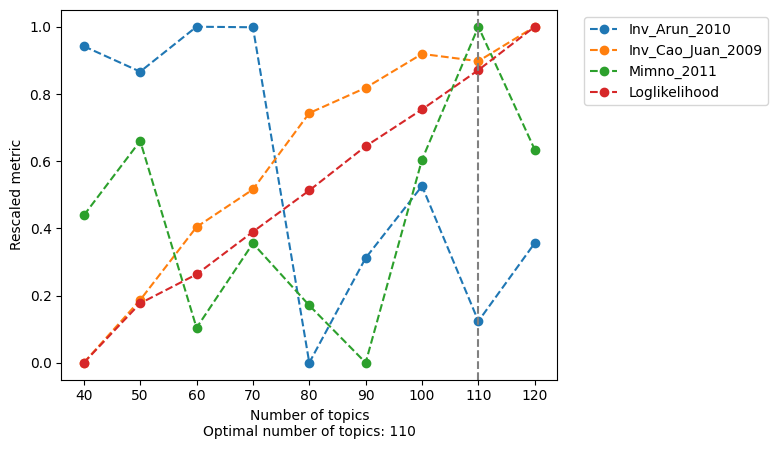

In [5]:
model = evaluate_models(
    models,
    return_model = True,
    select_model = 110,
    metrics=['Minmo_2011', 'loglikelihood', 'Arun_2010', 'Cao_Juan_2009'],
    plot = True,
    plot_metrics = False)

In [ ]:
## select model and save cto with topic model 
! topic_modeling/topic_modeling_05_select_model.sh CC 110 snATAC_analysis/out/CC/merged_CC_T2T_final.pkl

## 4. Annotation

In [ ]:
rna_annot_path = data_dir + 'cc_annotations_rna.csv'
rna_annot = pd.read_csv(rna_annot_path)

In [ ]:
infile = open(out + '/CC_T2T_final_80topics_ct2.pkl', 'rb')
cistopic_obj = pickle.load(infile)
infile.close()

In [ ]:
## add rna annotations for multiome cells 
cistopic_obj.add_cell_data(rna_annot)

In [ ]:
## find higher resolution clusters
find_clusters(
    cistopic_obj,
    target  = 'cell',
    k = 10,
    res = [4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5, 9.0, 9.5, 10.0],
    prefix = '110_pycisTopic_',
    scale = True,
    split_pattern = '-'
)

In [ ]:
## Function for annotation based on custom proportions and resolutions (majority voting)
def annotate(cistopic_obj, annotated_cells_df, annotated_cells_df_cell_type_variable, resolution_variable, proportions_list):
    # get cell types of interest
    print('column with annotations to use: ' + annotated_cells_df_cell_type_variable)
    print('column with resolution variable: ' + resolution_variable)
    print('proportions: ' + str(proportions_list))
    print()
    
    annotated_cells_df_cell_types = annotated_cells_df[annotated_cells_df_cell_type_variable].unique().tolist()
    annotated_cells_df_cell_types.append('total_cells')

    #create counts dataframe
    counts = pd.DataFrame(index = sorted(annotated_cells_df[resolution_variable].unique()),columns = annotated_cells_df_cell_types)
    print('fill in counts')
    #fill in counts
    for val in sorted(annotated_cells_df[resolution_variable].unique()):
        obs = annotated_cells_df[annotated_cells_df[resolution_variable] == val]
        counts['total_cells'][val] = obs[annotated_cells_df_cell_type_variable].value_counts().sum()
        for col in counts.columns:
            if col != 'total_cells':
                counts[col][val] = len(obs[obs[annotated_cells_df_cell_type_variable] == col])
    print()
    #make a proportions dataframe
    print('fill in proportions')
    proportions = counts.copy()
    for val in proportions.index:
        for col in proportions.columns:
            if col != 'total_cells':
                proportions[col][val] = int(proportions[col][val])/int(proportions['total_cells'][val])
        proportions['total_cells'][val] = 1
    proportions.drop(columns = ['total_cells'], inplace=True)
    print()

    #get the majority cell type per cluster
    print('get the majority cell type')
    majority_celltype = {}
    for index, row in proportions.iterrows():
        max_key = max(row.to_dict(), key=row.to_dict().get)
        #print(f"For row {index}, column '{max_key}' has the maximum value: {row.to_dict()[max_key]}")
        majority_celltype[index] =  max_key
    print()

    #create a column with the majority cell type: 
    print('fill in the majority cell type in the cto if it does not exist yet')
    if f'majority_celltype_{resolution_variable}' not in cistopic_obj.cell_data.columns:
        print(f'adding majority_celltype_{resolution_variable} since it does not exist yet')
        cistopic_obj.cell_data[f'majority_celltype_{resolution_variable}'] = np.nan
    else:
        print(f'majority_celltype_{resolution_variable} exists')
        
    for index, value in cistopic_obj.cell_data[resolution_variable].items():
        if value in majority_celltype:
            cistopic_obj.cell_data.at[index, f'majority_celltype_{resolution_variable}'] = majority_celltype[value]
    print()

    #create a column with the majority cell type with proportion cut-off
    for prop in proportions_list:

        print(f'fill in the majority cell type in the cto using cut-off {prop}')
        cistopic_obj.cell_data[f'majority_celltype_{resolution_variable}_{prop}_cutoff'] = 'unknown'
    
        for index, value in cistopic_obj.cell_data[resolution_variable].items():
            if  value in majority_celltype.keys():
                if proportions[majority_celltype[value]][value] > prop:
                    cistopic_obj.cell_data.at[index, f'majority_celltype_{resolution_variable}_{prop}_cutoff'] = majority_celltype[value]
                else:
                    cistopic_obj.cell_data.at[index, f'majority_celltype_{resolution_variable}_{prop}_cutoff'] = 'unknown'
        #change 'unknown' to na for plotting purposes
        print('make a column with NA')
        cistopic_obj.cell_data[f'majority_celltype_{resolution_variable}_{prop}_cutoff_na'] = cistopic_obj.cell_data[f'majority_celltype_{resolution_variable}_{prop}_cutoff'].replace('unknown',np.nan)
        print()

In [ ]:
## check all resolutions and proportions
annotate(cistopic_obj, annotated_cells, 'cell_type_RNA', '110_pycisTopic_leiden_10_3.5', [0.3,0.4,0.5,0.6,0.7,0.8])
annotate(cistopic_obj, annotated_cells, 'cell_type_RNA', '110_pycisTopic_leiden_10_4.0', [0.3,0.4,0.5,0.6,0.7,0.8])
annotate(cistopic_obj, annotated_cells, 'cell_type_RNA', '110_pycisTopic_leiden_10_4.5', [0.3,0.4,0.5,0.6,0.7,0.8])
annotate(cistopic_obj, annotated_cells, 'cell_type_RNA', '110_pycisTopic_leiden_10_5.0', [0.3,0.4,0.5,0.6,0.7,0.8])
annotate(cistopic_obj, annotated_cells, 'cell_type_RNA', '110_pycisTopic_leiden_10_5.5', [0.3,0.4,0.5,0.6,0.7,0.8])
annotate(cistopic_obj, annotated_cells, 'cell_type_RNA', '110_pycisTopic_leiden_10_6.0', [0.3,0.4,0.5,0.6,0.7,0.8])
annotate(cistopic_obj, annotated_cells, 'cell_type_RNA', '110_pycisTopic_leiden_10_6.5', [0.3,0.4,0.5,0.6,0.7,0.8])
annotate(cistopic_obj, annotated_cells, 'cell_type_RNA', '110_pycisTopic_leiden_10_7.0', [0.3,0.4,0.5,0.6,0.7,0.8])
annotate(cistopic_obj, annotated_cells, 'cell_type_RNA', '110_pycisTopic_leiden_10_7.5', [0.3,0.4,0.5,0.6,0.7,0.8])
annotate(cistopic_obj, annotated_cells, 'cell_type_RNA', '110_pycisTopic_leiden_10_8.0', [0.3,0.4,0.5,0.6,0.7,0.8])
annotate(cistopic_obj, annotated_cells, 'cell_type_RNA', '110_pycisTopic_leiden_10_8.5', [0.3,0.4,0.5,0.6,0.7,0.8])
annotate(cistopic_obj, annotated_cells, 'cell_type_RNA', '110_pycisTopic_leiden_10_9.0', [0.3,0.4,0.5,0.6,0.7,0.8])
annotate(cistopic_obj, annotated_cells, 'cell_type_RNA', '110_pycisTopic_leiden_10_9.5', [0.3,0.4,0.5,0.6,0.7,0.8])
annotate(cistopic_obj, annotated_cells, 'cell_type_RNA', '110_pycisTopic_leiden_10_10.0', [0.3,0.4,0.5,0.6,0.7,0.8])

In [ ]:
## check percentages
cols = [x for x in cistopic_obj.cell_data.columns if 'cutoff' in x]
cols = [x for x in cols if '_na' not in x]
res_df = cistopic_obj.cell_data[cols]
source_df = res_df
value_counts_dict = {}
for column in source_df.columns:
    counts = source_df[column].value_counts()
    value_counts_dict[column] = counts

# Convert the dictionary of Series to a DataFrame for easier manipulation
counts_df = pd.DataFrame(value_counts_dict).fillna(0)
percs = pd.DataFrame(index = counts_df.index, columns = counts_df.columns)
for col in counts_df.columns:
    percs[col] = (counts_df[col] / counts_df[col].sum()) #* 100

# Number of columns in the DataFrame
df = percs
n_cols = len(df.columns)

# Create a 14x6 grid of subplots
fig, axes = plt.subplots(14, 6, figsize=(18, 36))  # Adjust the figsize as needed
axes = axes.flatten()  # Flatten the 2D array of axes into a 1D array

# Plot each column in a separate subplot
for i, column in enumerate(df.columns):
    ax = axes[i]
    # Create the bar plot
    bars = df[column].plot(kind='bar', ax=ax, color='blue')

    # Get the index positions where the value is 0
    zero_indices = df.index[df[column] == 0]

    # Plot a faded red band for each bar with value 0
    for idx in zero_indices:
        bar_position = bars.patches[df.index.get_loc(idx)].get_x()
        bar_width = bars.patches[df.index.get_loc(idx)].get_width()

        # Add a faded red band (bar) with the same width as the original bar
        ax.bar(bar_position, df[column].max(), width=bar_width, color='red', alpha=0.3, edgecolor='none')

    # Set title and rotate x-axis labels
   # ax.set_title(column)
    ax.set_xticks(range(len(df.index)))  # Ensure all x-ticks are set
    ax.set_xticklabels(df.index, rotation=90)  # Rotate x-axis labels if needed

# Hide any unused subplots
for j in range(n_cols, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
## choose leiden 10, 9.5 with 70% cutoff
cistopic_obj.cell_data['CISTOPIC_2_final_annot'] = cistopic_obj.cell_data['majority_celltype_110_pycisTopic_leiden_10_9.5_0.7_cutoff']
cistopic_obj.cell_data['CISTOPIC_2_final_annot_NA'] = cistopic_obj.cell_data['majority_celltype_110_pycisTopic_leiden_10_9.5_0.7_cutoff_na']

### manual annotation of SNCG (cluster 14)

In [ ]:
for x in ['14']:
    print(cistopic_obj.cell_data[cistopic_obj.cell_data['110_pycisTopic_leiden_10_9.5'] == x]['cell_type_RNA'].value_counts())
sncg = cistopic_obj.cell_data[cistopic_obj.cell_data['110_pycisTopic_leiden_10_9.5'] == '14'].index
cistopic_obj.cell_data.loc[sncg, 'CISTOPIC_2_final_annot'] = cistopic_obj.cell_data.loc[sncg, 'CISTOPIC_2_final_annot'].replace({'unknown':'Sncg'})
cistopic_obj.cell_data.loc[sncg, 'CISTOPIC_2_final_annot_NA'] = (cistopic_obj.cell_data.loc[sncg, 'CISTOPIC_2_final_annot_NA'].fillna('Sncg'))

### Remove donor ASA_105

Lots of cells coming from this donor were forming a separate cluster (cluster 154), so we decided to remove this donor from dataset, as well as cells that were also in that one separate cluster. 

In [ ]:
## replace 
cistopic_obj.cell_data.loc[cistopic_obj.cell_data['110_pycisTopic_leiden_10_9.5'] == '154', 'CISTOPIC_2_final_annot'] = 'unknown'
cistopic_obj.cell_data.loc[cistopic_obj.cell_data['110_pycisTopic_leiden_10_9.5'] == '154', 'CISTOPIC_2_final_annot_NA'] = np.nan
cistopic_obj.cell_data.loc[cistopic_obj.cell_data['donor_id'] == 'ASA_105', 'CISTOPIC_2_final_annot'] = 'unknown'
cistopic_obj.cell_data.loc[cistopic_obj.cell_data['donor_id'] == 'ASA_105', 'CISTOPIC_2_final_annot_NA'] = np.nan

In [6]:
## rerun umap and tsne
exclude = ['unknown','doublet']
cells = cistopic_obj.cell_data[~cistopic_obj.cell_data['CISTOPIC_2_final_annot'].isin(exclude)].index
run_umap(cistopic_obj, target  = 'cell', scale=True, selected_features = cells, reduction_name = 'UMAP_110_celltypes_CT2final_9.5_0.7_masked_ASA105')
run_tsne(cistopic_obj, target  = 'cell', scale=True, selected_features = cells, reduction_name = 'tSNE_110_celltypes_CT2final_9.5_0.7_masked_ASA105')
run_umap(cistopic_obj, target  = 'cell', scale=True, selected_features = cells, reduction_name = 'UMAP_110_harmony_celltypes_CT2final_9.5_0.7_masked_ASA105', harmony = True)
run_tsne(cistopic_obj, target  = 'cell', scale=True, selected_features = cells, reduction_name = 'tSNE_110_harmony_celltypes_CT2final_9.5_0.7_masked_ASA105', harmony = True)

In [ ]:
with open(out + '/cistopic_objects/CC_T2T_final_110topics_ct2.pkl', 'wb') as f:  
    pickle.dump(cistopic_obj, f)

In [ ]:
## save annotations to csv:
cistopic_obj.cell_data.to_csv(out + 'cc_metadata_with_annotations.csv', index = True)

## 5. Pseudobulking and peak calling

In [ ]:
from pycisTopic.pseudobulk_peak_calling import export_pseudobulk

In [ ]:
samples = [x.split('_')[0] for x in cistopic_obj.cell_data.sample_id.unique()]

In [ ]:
fragments_dict = {
    os.path.basename(x).split(".")[0]: x
    for x in sorted(
        sorted(
            glob.glob(
                data_dir+"fragments/*.fragments.raw.tsv.gz"
            )
        )
    )
}
fragments_dict_subset = dict((k, fragments_dict[k]) for k in samples)

In [ ]:
cell_data = cistopic_obj.cell_data
cell_data['sample_id_short'] = [x.split('_')[0] for x in cell_data['sample_id']]

In [ ]:
chromsizes = pd.read_table(
    "http://hgdownload.cse.ucsc.edu/goldenPath/hs1/bigZips/hs1.chrom.sizes.txt",
    header = None,
    names = ["Chromosome", "End"]
)
chromsizes.insert(1, "Start", 0)

### 5.1 per cell type 

In [ ]:
os.makedirs(os.path.join(out, "consensus_peak_calling/"), exist_ok = True)
os.makedirs(os.path.join(out, "consensus_peak_calling/CISTOPIC_2_final_annot_bed"), exist_ok = True)
os.makedirs(os.path.join(out, "consensus_peak_calling/CISTOPIC_2_final_annot_bw"), exist_ok = True)

In [ ]:
bw_paths, bed_paths = export_pseudobulk(
    input_data = cell_data,
    variable = "CISTOPIC_2_final_annot",
    sample_id_col = "sample_id_short",
    chromsizes = chromsizes,
    bed_path = os.path.join(out, "consensus_peak_calling/CISTOPIC_2_final_annot_bed"),
    bigwig_path = os.path.join(out, "consensus_peak_calling/CISTOPIC_2_final_annot_bw"),
    path_to_fragments = fragments_dict_subset,
    n_cpu = 10,
    normalize_bigwig = True,
    temp_dir = "/tmp",
    split_pattern = "-"
)

print('save paths')
with open(os.path.join(out, "consensus_peak_calling/CISTOPIC_2_final_annot_bed_paths.tsv"), "wt") as f:
    for v in bw_paths:
        _ = f.write(f"{v}\t{bw_paths[v]}\n")

with open(os.path.join(out, "consensus_peak_calling/CISTOPIC_2_final_annot_bw_paths.tsv"), "wt") as f:
    for v in bed_paths:
        _ = f.write(f"{v}\t{bed_paths[v]}\n")

### 5.2 per donor and cell type 

In [ ]:
cell_data['donor_cell_type'] = cell_data['donor_id'] + '_' + cell_data['CISTOPIC_2_final_annot']
## add cell count
counts = cell_data['donor_cell_type'].value_counts().reset_index()
counts.columns = ['donor_cell_type', 'count']
counts['count'] = counts['count'].astype(str)
cell_data = cell_data.merge(counts, on='donor_cell_type', how='left')
cell_data['donor_cell_type_counts_pseudobulk'] = cell_data['donor_cell_type'] + '__' + cell_data['count'].astype(str)
cell_data.drop(columns=['count'], inplace=True)

In [ ]:
os.makedirs(os.path.join(out, "consensus_peak_calling/donor_cell_type_bed"), exist_ok = True)
os.makedirs(os.path.join(out, "consensus_peak_calling/donor_cell_type_bw"), exist_ok = True)

In [ ]:
bw_paths, bed_paths = export_pseudobulk(
    input_data = cell_data,
    variable = "donor_cell_type_counts_pseudobulk",
    sample_id_col = "sample_id_short",
    chromsizes = chromsizes,
    bed_path = os.path.join(out, "consensus_peak_calling/donor_cell_type_bed"),
    bigwig_path = os.path.join(out, "consensus_peak_calling/donor_cell_type_bw"),
    path_to_fragments = fragments_dict_subset,
    n_cpu = 10,
    normalize_bigwig = True,
    temp_dir = "/tmp",
    split_pattern = "-"
)

print('save paths')
with open(os.path.join(out, "consensus_peak_calling/donor_cell_type_bw_paths.tsv"), "wt") as f:
    for v in bw_paths:
        _ = f.write(f"{v}\t{bw_paths[v]}\n")

with open(os.path.join(out, "consensus_peak_calling/donor_cell_type_bed_paths.tsv"), "wt") as f:
    for v in bed_paths:
        _ = f.write(f"{v}\t{bed_paths[v]}\n")


### 5.3 Peak calling (from cell type pseudobulks)

In [ ]:
bed_paths = {}
with open(os.path.join(out, "consensus_peak_calling/CISTOPIC_2_final_annot_bed_paths.tsv")) as f:
    for line in f:
        v, p = line.strip().split("\t")
        bed_paths.update({v: p})

In [ ]:
# open file paths
bw_paths = {}
with open(os.path.join(out, "consensus_peak_calling/CISTOPIC_2_final_annot_bw_paths.tsv")) as f:
    for line in f:
        v, p = line.strip().split("\t")
        bw_paths.update({v: p})

In [ ]:
from pycisTopic.pseudobulk_peak_calling import peak_calling
macs_path = "macs2"

os.makedirs(os.path.join(out, "consensus_peak_calling/MACS"), exist_ok = True)

narrow_peak_dict = peak_calling(
    macs_path = macs_path,
    bed_paths = bed_paths,
    outdir = os.path.join(os.path.join(out, "consensus_peak_calling/MACS")),
    genome_size = 'hs',
    n_cpu = 4,
    input_format = 'BEDPE',
    shift = 73,
    ext_size = 146,
    keep_dup = 'all',
    q_value = 0.05,
    _temp_dir = '/tmp'
)

In [ ]:
def load_narrow_peak(outdir, ct):
        """
        Load MACS2 narrow peak files as :class:`pr.PyRanges`.
        """
        # check if file is empty
        with open(os.path.join(outdir, f"{ct}_peaks.narrowPeak")) as f:
            first_line = f.readline()
            if len(first_line) == 0:
                file_is_empty = True
        narrow_peak = pd.read_csv(
            os.path.join(outdir, f"{ct}_peaks.narrowPeak"),
            sep="\t",
            header=None,
        )
        narrow_peak.columns = [
            "Chromosome",
            "Start",
            "End",
            "Name",
            "Score",
            "Strand",
            "FC_summit",
            "-log10_pval",
            "-log10_qval",
            "Summit",
        ]
        narrow_peak_pr = pr.PyRanges(narrow_peak)
        return narrow_peak_pr

In [ ]:
macs_folder = out + 'consensus_peak_calling/MACS'
narrow_peaks_dict = {}
for key in bed_paths.keys():
    narrow_peaks_dict[key] = load_narrow_peak(macs_folder, key)

In [ ]:
from pycisTopic.iterative_peak_calling import get_consensus_peaks
peak_half_width=250
path_to_blacklist=data_dir 'hg38-blacklist.v2_to_T2T.bed'
# Get consensus peaks
consensus_peaks = get_consensus_peaks(
    narrow_peaks_dict = narrow_peaks_dict,
    peak_half_width = peak_half_width,
    chromsizes = chromsizes,
    path_to_blacklist = path_to_blacklist)

In [ ]:
consensus_peaks.to_bed(
    path = os.path.join(out, "consensus_peak_calling/CC_CT2_consensus_regions.bed"),
    keep =True,
    compression = 'infer',
    chain = False)

## 06. DARs

In [ ]:
from pycisTopic.diff_features import *

In [ ]:
## impute accessibility 
imputed_acc_obj = impute_accessibility(cistopic_obj, selected_cells=None, selected_regions=None, scale_factor=10**6)
imputed_acc_obj = normalize_scores(imputed_acc_obj, scale_factor=10**4)

## get variable regions
variable_regions = find_highly_variable_features(imputed_acc_obj,
                                           min_disp = 0.05,
                                           min_mean = 0.0125, 
                                           max_mean = 3,
                                           max_disp = np.inf,
                                           n_bins=20, 
                                           n_top_features=None,
                                           plot=False,
                                           save= out + 'DARs/HVR_plot.pdf')

# save variable regions
with gzip.open(out + 'DARs/variable_regions.pkl.gz', 'wb', compresslevel=4) as f:
    pickle.dump(variable_regions, f)

markers_dict= find_diff_features(cistopic_obj, 
                                 imputed_acc_obj,
                                 variable=anno,
                                 var_features=variable_regions,
                                 contrasts=None,
                                 adjpval_thr=0.05,
                                 log2fc_thr=np.log2(1.5),
                                 n_cpu=njobs,                                 
                                 split_pattern = '-',
                                 _temp_dir=raydir,
                                 object_store_memory = 650 * 1024 * 1024 * 1024,
                                 _memory = 1300 * 1024 * 1024 * 1024
                                 )

with gzip.open(out + 'DARs/DARs.pkl.gz', 'wb', compresslevel=4) as f:
    pickle.dump(markers_dict, f)

## 07. Fragment matrices with final peak set (for caQTL/ASCA)

In [ ]:
consensus_peaks_path = out + "consensus_peak_calling/CC_CT2_consensus_regions.bed"
path_to_blacklist = data_dir + 'hg38-blacklist.v2_to_T2T.bed'
cistopic_objects_out = out + '/cistopic_objects_CT2_peaks/'
tss = pd.read_csv(data_dir + "T2T_TSS_full.bed", index_col = 0,  sep = '\t')

### 7.1 CC only samples

In [ ]:
## read metadata
metadata = pl.read_csv(metadata_path)
metadata = (metadata.filter(pl.col("brain_region") == "cyngulate_cortex").sort(pl.col("short_bc_id")))

## fragments
fragments_dict = {
    os.path.basename(x).split(".")[0]: x
    for x in sorted(glob.glob(data_dir+"fragments/*.fragments.raw.tsv.gz")
    )
}
fragments_dict = dict((k, fragments_dict[k]) for k in metadata['short_bc_id'])#if k in fragments_dict.keys())

consensus_dict = {}
for k in fragments_dict:
    consensus_dict[k] = consensus_peaks_path

## get barcodes
sample_id_to_barcodes_passing_filters = {}
sample_id_to_thresholds = {}
parquet_dict = {
    os.path.basename(x).split(".")[0]: x
    for x in sorted(
        sorted(glob.glob(out + "QC/*.fragments_stats_per_cb.parquet"
            )
        )
    )
}
parquet_samples = [key for key in parquet_dict.keys()]
for sample_id in parquet_samples:
    (sample_id_to_barcodes_passing_filters[sample_id],sample_id_to_thresholds[sample_id]) = get_barcodes_passing_qc_for_sample(
            sample_id = sample_id,
            pycistopic_qc_output_dir =  out+'/QC/',
            unique_fragments_threshold = 1000,
            tss_enrichment_threshold = 5,
            frip_threshold = 0,
            use_automatic_thresholds = True,
    )

## make objects
for sample in parquet_samples:
    cto = os.path.join(cistopic_objects_out, sample + "__cto.pkl")
    if not os.path.exists(cto):
        print(sample)
    print(f"Checking if {cto} exist...")
    if os.path.exists(cto):
        print(f"\t{cto} exists! Skipping...")
        print()
    elif os.path.exists(os.path.join(out,f'QC/{sample}.fragments_stats_per_cb.parquet')):
        print(sample)
        print(f"\t{cto} generating...")
        sample_metrics = pl.read_parquet(os.path.join(out, f'QC/{sample}.fragments_stats_per_cb.parquet')).to_pandas().set_index("CB").loc[ sample_id_to_barcodes_passing_filters[sample] ]
        cistopic_obj = create_cistopic_object_from_fragments(
            path_to_fragments = fragments_dict[sample],
            path_to_regions = consensus_peaks_path,
            path_to_blacklist = path_to_blacklist,
            metrics = sample_metrics,
            valid_bc = sample_id_to_barcodes_passing_filters[sample],
            n_cpu = 10,
            project = sample,
            partition=100)
        print(f"Writing {sample} cto in {cto}...")
        with open(cto, "wb") as f:
            pickle.dump(cistopic_obj, f, protocol=4)
    else:
        print(f'{sample} has no parquet')     

### 7.2 Mixed samples

In [ ]:
## read metadata
metadata = pl.read_csv(metadata_path)
metadata = (metadata.filter(pl.col("brain_region") == "cyngulate_cortex.substantia_nigra").sort(pl.col("short_bc_id")))

## fragments
fragments_dict = {
    os.path.basename(x).split(".")[0]: x
    for x in sorted(glob.glob(data_dir+"fragments/*.fragments.raw.tsv.gz")
    )
}
fragments_dict = dict((k, fragments_dict[k]) for k in metadata['short_bc_id'])

consensus_dict = {}
for k in fragments_dict:
    consensus_dict[k] = consensus_peaks_path

## get barcodes
sample_id_to_barcodes_passing_filters = {}
sample_id_to_thresholds = {}
parquet_dict = {
    os.path.basename(x).split(".")[0]: x
    for x in sorted(
        sorted(glob.glob(out + "QC/*.fragments_stats_per_cb.parquet"
            )
        )
    )
}
for sample_id in fragments_dict.keys():
    (sample_id_to_barcodes_passing_filters[sample_id],sample_id_to_thresholds[sample_id]) = get_barcodes_passing_qc_for_sample(
            sample_id = sample_id,
            pycistopic_qc_output_dir =  out+'/QC/',
            unique_fragments_threshold = 1000,
            tss_enrichment_threshold = 5,
            frip_threshold = 0,
            use_automatic_thresholds = True,
    )

## make objects
for sample in parquet_samples:
    cto = os.path.join(cistopic_objects_out, sample + "__cto.pkl")
    if not os.path.exists(cto):
        print(sample)
    print(f"Checking if {cto} exist...")
    if os.path.exists(cto):
        print(f"\t{cto} exists! Skipping...")
        print()
    elif os.path.exists(os.path.join(out,f'QC/{sample}.fragments_stats_per_cb.parquet')):
        print(sample)
        print(f"\t{cto} generating...")
        sample_metrics = pl.read_parquet(os.path.join(out, f'QC/{sample}.fragments_stats_per_cb.parquet')).to_pandas().set_index("CB").loc[ sample_id_to_barcodes_passing_filters[sample] ]
        cistopic_obj = create_cistopic_object_from_fragments(
            path_to_fragments = fragments_dict[sample],
            path_to_regions = consensus_peaks_path,
            path_to_blacklist = path_to_blacklist,
            metrics = sample_metrics,
            valid_bc = sample_id_to_barcodes_passing_filters[sample],
            n_cpu = 10,
            project = sample,
            partition=100)
        print(f"Writing {sample} cto in {cto}...")
        with open(cto, "wb") as f:
            pickle.dump(cistopic_obj, f, protocol=4)
    else:
        print(f'{sample} has no parquet')     

### 7.3 Merge objects and add metadata

In [ ]:
ctos = os.listdir(cistopic_objects_out)
samples = []
data_dict = {}
loaded_cto_list = []

for cto in ctos:
    if 'pkl' in cto:
        sample_name = cto.split('__')[0]
        print(sample_name)
        samples.append(sample_name)
        infile = open(out +f'/cistopic_objects/{cto}', 'rb')
        data_dict[sample_name] = pickle.load(infile)
        infile.close()
        loaded_cto_list.append(data_dict[sample_name])

In [ ]:
cell_annotations_path = out + 'cc_metadata_with_annotations.csv'
cell_annotations = pd.read_csv(cell_annotations_path, index_col=0)

In [ ]:
# merge and save the object
cistopic_obj = merge(loaded_cto_list)
cistopic_obj.add_cell_data(cell_annotations)
with open(out+'/merged_CC_T2T_CT2.pkl', 'wb') as f:
    pickle.dump(cistopic_obj, f)